# Pure Theoretical CMB Maps — Planck 2018 Best-Fit Baseline

Generates a single set of clean CMB maps from the **unlensed theoretical power spectrum** computed by CAMB using Planck 2018 best-fit ΛCDM parameters.

**No beam, no instrumental noise, no galactic mask.** The only stochasticity is cosmic variance — one Gaussian random field realisation drawn from the theoretical $C_\ell$ arrays.

**Outputs**
- 5 FITS maps: `T`, `Q`, `U`, `E`, `B` (nside=256, float32)
- `meta_theory_planck.json` — Planck 2018 parameters, `nside`, `seed`, `lmax`
- `spectra_theory_planck.npz` — $\ell$, $D_\ell$ and $C_\ell$ arrays for TT, TE, EE, BB (=0), TB (=0)

BB is identically zero because we use the **unlensed** scalar spectrum — there are no primordial tensor modes and no lensing-induced B-modes. TB is zero by parity symmetry in standard ΛCDM. This makes the dataset an ideal benchmark: any non-zero BB or TB in downstream analyses flags a systematic or analysis artefact.

In [3]:
import os
import json
import datetime
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import camb

from skysimulation import generate_camb_power_spectra

print(f'CAMB version: {camb.__version__}')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

CAMB version: 1.6.6


## 1. Configuration

In [4]:
# ── Resolution ────────────────────────────────────────────────────────────────
nside = 256
lmax  = 3 * nside   # natural limit for nside=256; CAMB computed to this ell
seed  = 314100

# ── Planck 2018 best-fit ΛCDM parameters (Table 2, arXiv:1807.06209) ─────────
planck_params = dict(
    H0    = 67.36,
    ombh2 = 0.02237,   # Omega_b h^2
    omch2 = 0.1200,    # Omega_cdm h^2
    mnu   = 0.06,      # sum of neutrino masses [eV]
    omk   = 0.0,       # spatial curvature
    tau   = 0.0544,    # optical depth to reionisation
    As    = 2.101e-9,  # primordial scalar amplitude  (ln(10^10 As) = 3.044)
    ns    = 0.9649,    # scalar spectral index
)

# ── Output paths ──────────────────────────────────────────────────────────────
_maps_base = '/nvme/h/lchristodoulou/data_p318'
out_dir    = os.path.join(_maps_base, 'theory_baseline')
os.makedirs(out_dir, exist_ok=True)

print(f'nside={nside}  lmax={lmax}  seed={seed}')
print(f'Output directory: {out_dir}')

nside=256  lmax=768  seed=314100
Output directory: /nvme/h/lchristodoulou/data_p318/theory_baseline


## 2. Theoretical Power Spectra (CAMB)

`generate_camb_power_spectra` returns $D_\ell = \frac{\ell(\ell+1)}{2\pi}C_\ell$ in $\mu K^2$ for the **unlensed scalar** spectra. BB and TB are identically zero in this approximation.

In [5]:
spectra = generate_camb_power_spectra(
    planck_params['H0'],
    planck_params['ombh2'],
    planck_params['omch2'],
    planck_params['mnu'],
    planck_params['omk'],
    tau  = planck_params['tau'],
    As   = planck_params['As'],
    ns   = planck_params['ns'],
    lmax = lmax,
)

ell    = spectra.ell           # integer ell from 0 to lmax
dl_tt  = spectra.tt            # D_ell TT  [muK^2]
dl_te  = spectra.te            # D_ell TE  [muK^2]
dl_ee  = spectra.ee            # D_ell EE  [muK^2]
dl_bb  = np.zeros_like(dl_tt)  # BB = 0 (unlensed, no tensors)
dl_tb  = np.zeros_like(dl_tt)  # TB = 0 (parity symmetry)

print(f'Spectra computed: ell = [{ell[0]}, {ell[-1]}]')
print(f'TT peak Dl = {dl_tt.max():.1f} muK^2  at ell = {ell[dl_tt.argmax()]}')

Spectra computed: ell = [0, 800]
TT peak Dl = 5743.5 muK^2  at ell = 220


## 3. Visualise Power Spectra

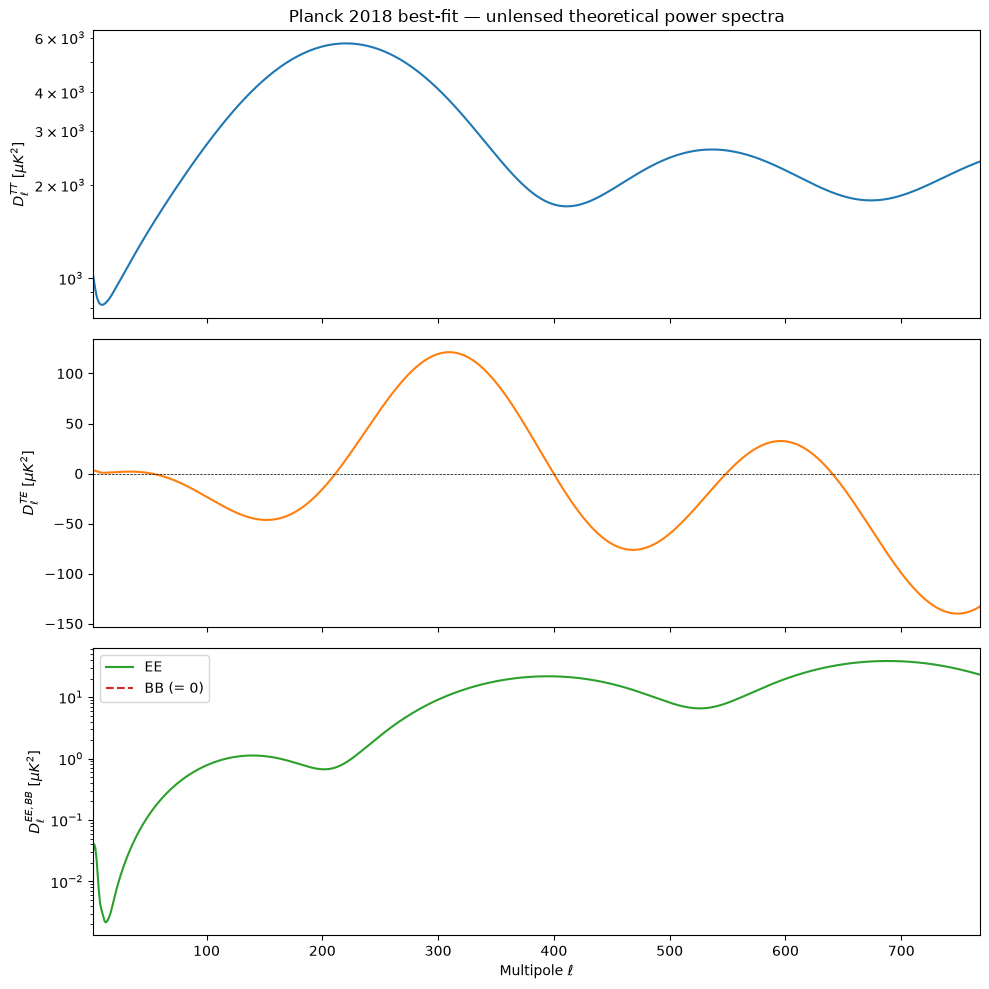

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(ell[2:], dl_tt[2:], 'C0', lw=1.5)
axes[0].set_ylabel(r'$D_\ell^{TT}\ [\mu K^2]$')
axes[0].set_yscale('log')
axes[0].set_title('Planck 2018 best-fit — unlensed theoretical power spectra')

axes[1].plot(ell[2:], dl_te[2:], 'C1', lw=1.5)
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_ylabel(r'$D_\ell^{TE}\ [\mu K^2]$')

axes[2].plot(ell[2:], dl_ee[2:], 'C2', lw=1.5, label='EE')
axes[2].plot(ell[2:], dl_bb[2:], 'C3', lw=1.5, ls='--', label='BB (= 0)')
axes[2].set_ylabel(r'$D_\ell^{EE,BB}\ [\mu K^2]$')
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_yscale('log')
axes[2].legend()

for ax in axes:
    ax.set_xlim(2, lmax)

plt.tight_layout()
plt.show()

## 4. Convert $D_\ell \to C_\ell$ for `hp.synfast`

`hp.synfast` expects $C_\ell$ arrays indexed from $\ell = 0$:
$$C_\ell = \frac{2\pi}{\ell(\ell+1)}\,D_\ell, \quad \ell \ge 2; \qquad C_0 = C_1 = 0$$

In [7]:
def dl_to_cl(ell_arr, dl_arr):
    """D_ell -> C_ell, ell=0,1 set to zero."""
    cl = np.zeros_like(dl_arr)
    mask = ell_arr >= 2
    cl[mask] = 2 * np.pi / (ell_arr[mask] * (ell_arr[mask] + 1)) * dl_arr[mask]
    return cl

cl_tt = dl_to_cl(ell, dl_tt)
cl_te = dl_to_cl(ell, dl_te)
cl_ee = dl_to_cl(ell, dl_ee)
cl_bb = np.zeros_like(cl_tt)   # BB = 0
cl_eb = np.zeros_like(cl_tt)   # EB = 0  (parity)
cl_tb = np.zeros_like(cl_tt)   # TB = 0  (parity)

print(f'Cl arrays ready: {len(cl_tt)} entries (ell 0 to {len(cl_tt)-1})')
print(f'cl_tt peak = {cl_tt.max():.4e} muK^2  at ell = {ell[cl_tt.argmax()]}')

Cl arrays ready: 801 entries (ell 0 to 800)
cl_tt peak = 1.0713e+03 muK^2  at ell = 2


## 5. Synthesise CMB Maps

`hp.synfast` draws one Gaussian random realisation. The resulting scatter around the input $C_\ell$ is pure **cosmic variance** — no other noise source is present.

E and B maps are derived from the (Q, U) polarisation maps via spin-2 spherical harmonic decomposition.

In [8]:
np.random.seed(seed)

T_map, Q_map, U_map = hp.synfast(
    [cl_tt, cl_ee, cl_bb, cl_te, cl_eb, cl_tb],
    nside=nside, new=True, pol=True,
)

# Derive E and B maps from Q, U via alm decomposition
_, alm_E, alm_B = hp.map2alm([T_map, Q_map, U_map], pol=True)
E_map = hp.alm2map(alm_E, nside=nside)
B_map = hp.alm2map(alm_B, nside=nside)

for name, m in [('T', T_map), ('Q', Q_map), ('U', U_map), ('E', E_map), ('B', B_map)]:
    print(f'{name}: mean={m.mean():+.4f}  std={m.std():.4f}  muK')

T: mean=+0.0000  std=105.1534  muK
Q: mean=+0.0031  std=3.1845  muK
U: mean=+0.0000  std=3.1915  muK
E: mean=-0.0000  std=4.4613  muK
B: mean=-0.0000  std=0.0269  muK


## 6. Visualise Maps

/tmp/ipykernel_493999/3293492492.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


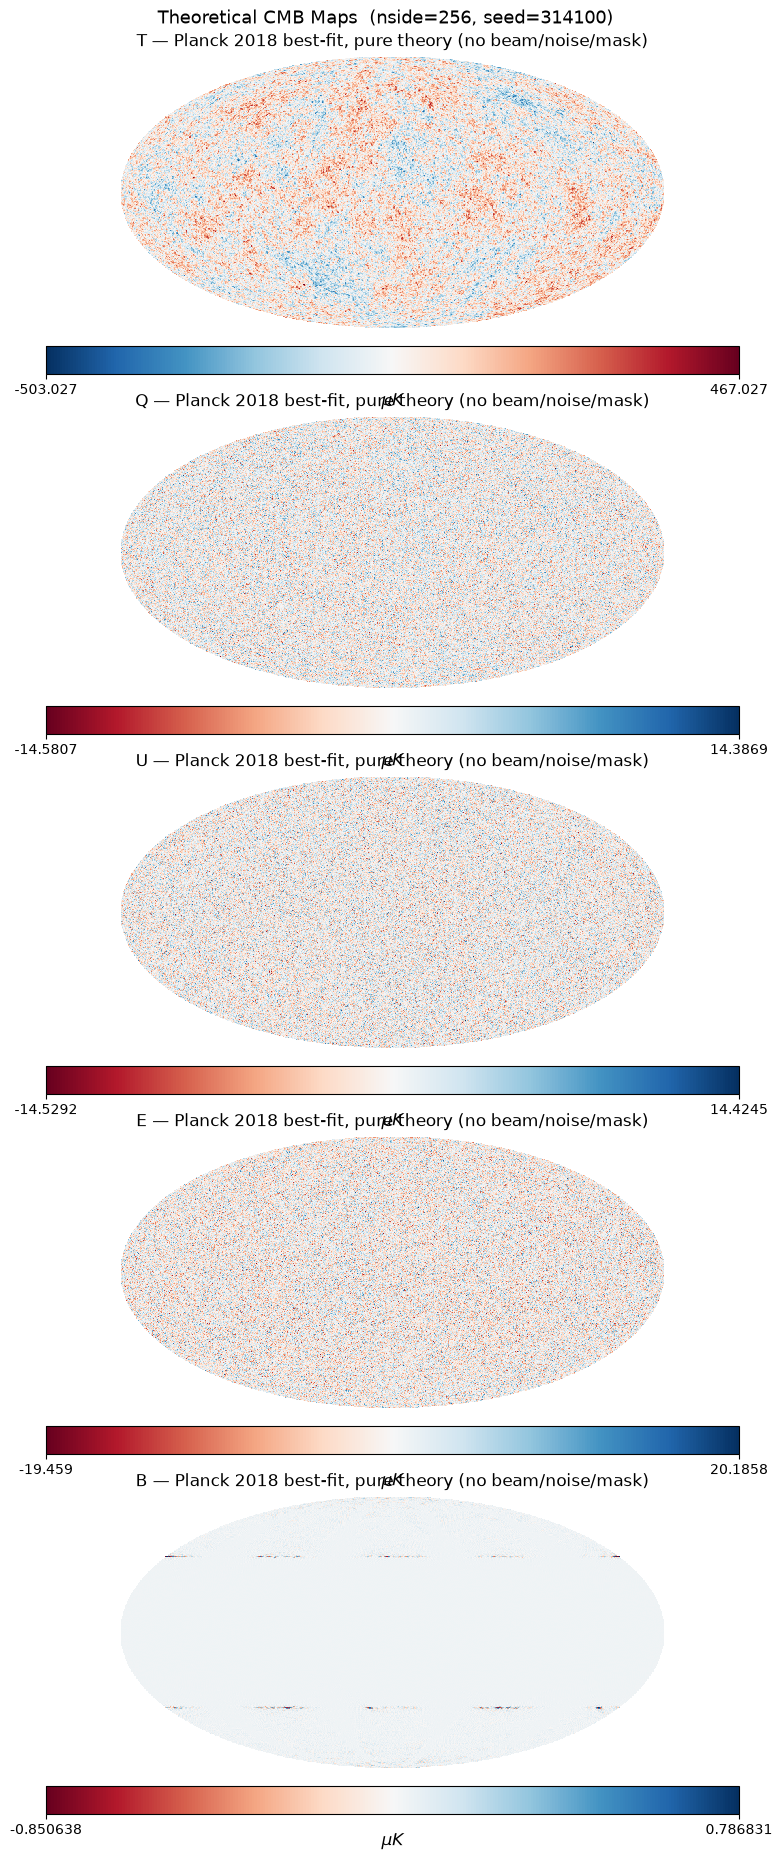

In [9]:
fig = plt.figure(figsize=(14, 18))
maps_to_plot = [
    ('T', T_map, 'RdBu_r'),
    ('Q', Q_map, 'RdBu'),
    ('U', U_map, 'RdBu'),
    ('E', E_map, 'RdBu'),
    ('B', B_map, 'RdBu'),
]
for i, (name, m, cmap) in enumerate(maps_to_plot, 1):
    hp.mollview(m, fig=fig, sub=(5, 1, i),
                title=f'{name} — Planck 2018 best-fit, pure theory (no beam/noise/mask)',
                unit=r'$\mu K$', cmap=cmap)

plt.suptitle(f'Theoretical CMB Maps  (nside={nside}, seed={seed})', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

## 7. Sanity Checks

Recover pseudo-$C_\ell$ from the T map and compare against the input spectrum. Because the full sky is used (no mask), $f_{\rm sky} = 1$ and no correction is needed.

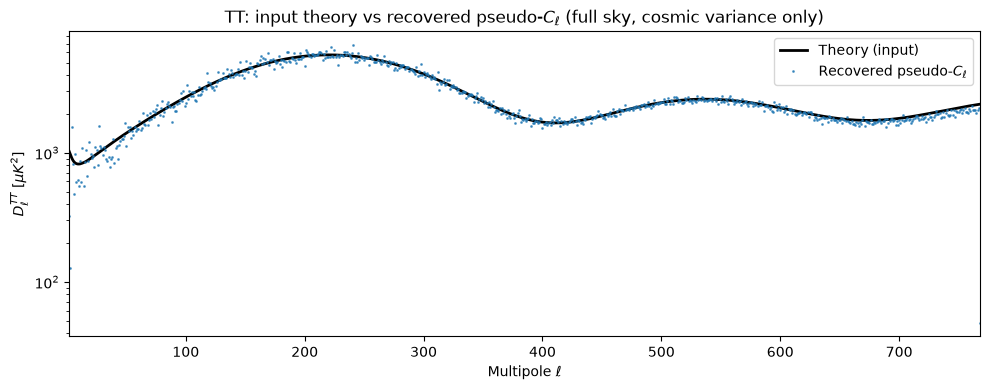

⟨Cl_EE⟩ / ⟨Cl_BB⟩ = 1.6e+05  (should be >> 1)

Map statistics:
  T: mean=+0.0000  std=105.1534  muK
  Q: mean=+0.0031  std=3.1845  muK
  U: mean=+0.0000  std=3.1915  muK
  E: mean=-0.0000  std=4.4613  muK
  B: mean=-0.0000  std=0.0269  muK


In [10]:
# Power spectrum recovery
# hp.anafast returns lmax+1 elements; CAMB may return slightly more — use a local ell array
cl_recovered_tt = hp.anafast(T_map, lmax=lmax)
ell_rec = np.arange(len(cl_recovered_tt))
dl_recovered_tt = ell_rec * (ell_rec + 1) / (2 * np.pi) * cl_recovered_tt

# Clip theory to the same ell range for comparison
n_rec = len(ell_rec)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ell_rec[2:], dl_tt[:n_rec][2:], 'k-', lw=2, label='Theory (input)')
ax.plot(ell_rec[2:], dl_recovered_tt[2:], 'C0.', ms=2, alpha=0.7, label=r'Recovered pseudo-$C_\ell$')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell^{TT}\ [\mu K^2]$')
ax.set_yscale('log')
ax.set_xlim(2, lmax)
ax.legend()
ax.set_title(r'TT: input theory vs recovered pseudo-$C_\ell$ (full sky, cosmic variance only)')
plt.tight_layout()
plt.show()

# E/B ratio — B should be ~0 (just numerical noise)
cl_E = hp.anafast(E_map, lmax=lmax)
cl_B = hp.anafast(B_map, lmax=lmax)
ratio = cl_E[2:].mean() / (cl_B[2:].mean() + 1e-30)
print(f'⟨Cl_EE⟩ / ⟨Cl_BB⟩ = {ratio:.1e}  (should be >> 1)')

# Map statistics
print('\nMap statistics:')
for name, m in [('T', T_map), ('Q', Q_map), ('U', U_map), ('E', E_map), ('B', B_map)]:
    print(f'  {name}: mean={m.mean():+.4f}  std={m.std():.4f}  muK')

## 8. Save Maps and Meta File

In [11]:
# ── FITS maps ─────────────────────────────────────────────────────────────────
for name, m in [('T', T_map), ('Q', Q_map), ('U', U_map), ('E', E_map), ('B', B_map)]:
    path = os.path.join(out_dir, f'{name}_theory_planck_nside{nside}.fits')
    hp.write_map(path, m, dtype=np.float32, overwrite=True)
    print(f'Saved {path}')

# ── Spectra (Dl and Cl) ───────────────────────────────────────────────────────
spectra_path = os.path.join(out_dir, 'spectra_theory_planck.npz')
np.savez(
    spectra_path,
    ell   = ell,
    dl_tt = dl_tt,
    dl_te = dl_te,
    dl_ee = dl_ee,
    dl_bb = dl_bb,
    dl_tb = dl_tb,
    cl_tt = cl_tt,
    cl_te = cl_te,
    cl_ee = cl_ee,
    cl_bb = cl_bb,
    cl_tb = cl_tb,
)
print(f'Saved {spectra_path}')

# ── JSON metadata ─────────────────────────────────────────────────────────────
meta = {
    'description'       : 'Pure theoretical CMB baseline — Planck 2018 best-fit ΛCDM, unlensed spectra, no beam/noise/mask',
    'created'           : datetime.datetime.utcnow().isoformat() + 'Z',
    'nside'             : nside,
    'lmax'              : int(lmax),
    'seed'              : seed,
    'spectra_type'      : 'unlensed_scalar',
    'units'             : 'muK',
    'beam_fwhm_arcmin'  : 0.0,
    'noise'             : 'none',
    'mask'              : 'none',
    'planck_params'     : planck_params,
    'reference'         : 'Planck 2018 TT,TE,EE+lowE+lensing, Table 2, arXiv:1807.06209',
    'spectra_file'      : 'spectra_theory_planck.npz',
    'spectra_arrays'    : {
        'ell'   : 'integer ell from 0 to lmax',
        'dl_*'  : 'D_ell = ell*(ell+1)/(2pi) * C_ell  [muK^2]',
        'cl_*'  : 'C_ell  [muK^2]',
        'dl_bb' : 'identically zero — unlensed scalar spectrum, no primordial tensors',
        'dl_tb' : 'identically zero — parity symmetry',
    },
}

meta_path = os.path.join(out_dir, 'meta_theory_planck.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Saved {meta_path}')

print(f'\nDone. All files written to {out_dir}/')

Saved /nvme/h/lchristodoulou/data_p318/theory_baseline/T_theory_planck_nside256.fits
Saved /nvme/h/lchristodoulou/data_p318/theory_baseline/Q_theory_planck_nside256.fits
Saved /nvme/h/lchristodoulou/data_p318/theory_baseline/U_theory_planck_nside256.fits
Saved /nvme/h/lchristodoulou/data_p318/theory_baseline/E_theory_planck_nside256.fits
Saved /nvme/h/lchristodoulou/data_p318/theory_baseline/B_theory_planck_nside256.fits
Saved /nvme/h/lchristodoulou/data_p318/theory_baseline/spectra_theory_planck.npz
Saved /nvme/h/lchristodoulou/data_p318/theory_baseline/meta_theory_planck.json

Done. All files written to /nvme/h/lchristodoulou/data_p318/theory_baseline/


/tmp/ipykernel_493999/3868472246.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'created'           : datetime.datetime.utcnow().isoformat() + 'Z',


## 9. 1000 Realisations — `planck_base`

Same Planck 2018 best-fit $C_\ell$ arrays as above. No beam, no noise, no mask. Each realisation uses a different seed (`seed + i`) so cosmic variance varies across maps while the underlying power spectrum is identical. One JSON meta file is sufficient — the parameters are constant across all realisations and the seed for realisation `i` is always `seed + i`.

In [12]:
from tqdm.notebook import tqdm

out_dir_sims = '/nvme/h/lchristodoulou/data_p318/planck_base'
os.makedirs(out_dir_sims, exist_ok=True)

tag_base = f'planck_base_nside{nside}'

for i in tqdm(range(1000), desc='planck_base'):
    seed_i = seed + i
    np.random.seed(seed_i)

    T, Q, U = hp.synfast(
        [cl_tt, cl_ee, cl_bb, cl_te, cl_eb, cl_tb],
        nside=nside, new=True, pol=True,
    )

    _, alm_E, alm_B = hp.map2alm([T, Q, U], pol=True)
    E = hp.alm2map(alm_E, nside=nside)
    B = hp.alm2map(alm_B, nside=nside)

    for comp, m in [('T', T), ('Q', Q), ('U', U), ('E', E), ('B', B)]:
        hp.write_map(
            os.path.join(out_dir_sims, f'{comp}_{tag_base}_{i:04d}.fits'),
            m, dtype=np.float32, overwrite=True,
        )

# Single JSON — parameters identical for all realisations; seed_i = seed + i
meta_sims = {
    **meta,
    'description'    : 'Planck 2018 best-fit ΛCDM, 1000 realisations — pure cosmic variance, no beam/noise/mask',
    'output_dir'     : out_dir_sims,
    'n_realisations' : 1000,
    'seed_scheme'    : 'seed_i = seed + i  (i = 0 … 999)',
    'file_pattern'   : f'{{comp}}_{tag_base}_{{i:04d}}.fits',
    'components'     : ['T', 'Q', 'U', 'E', 'B'],
}
meta_path = os.path.join(out_dir_sims, 'meta_planck_base.json')
with open(meta_path, 'w') as f:
    json.dump(meta_sims, f, indent=2)

print(f'\nDone. 1000 × 5 maps → {out_dir_sims}/')
print(f'Metadata  → {meta_path}')

planck_base:   0%|          | 0/1000 [00:00<?, ?it/s]


Done. 1000 × 5 maps → /nvme/h/lchristodoulou/data_p318/planck_base/
Metadata  → /nvme/h/lchristodoulou/data_p318/planck_base/meta_planck_base.json
